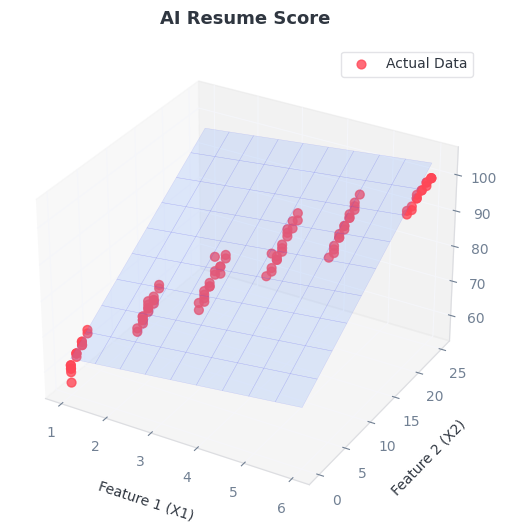

In [13]:
import tkinter as tk
from tkinter import ttk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.linear_model import LinearRegression


plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#ffffff",
    "axes.edgecolor": "#dcdde1",
    "axes.labelcolor": "#2f3640",
    "text.color": "#2f3640",
    "xtick.color": "#718093",
    "ytick.color": "#718093",
    "grid.color": "#f5f6fa",
})


df = pd.read_csv("dataset.csv")

X1 = df['Certificate']
X2 = df['Experience']
Y = df['Resume Score']

X = np.column_stack((X1, X2))

model = LinearRegression()
model.fit(X, Y)

x1_range = np.linspace(X1.min(), X1.max(), 10)
x2_range = np.linspace(X2.min(), X2.max(), 10)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

Y_pred = model.predict(np.column_stack((X1_grid.ravel(), X2_grid.ravel())))
Y_pred = Y_pred.reshape(X1_grid.shape)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# Red shows actual data
ax.scatter(X1, X2, Y, color='#ff4757', s=40, label='Actual Data', alpha=0.8)
ax.plot_surface(X1_grid, X2_grid, Y_pred, color='#70a1ff', alpha=0.2, edgecolor='#5352ed', linewidth=0.3)

ax.set_xlabel("Feature 1 (X1)", labelpad=10)
ax.set_ylabel("Feature 2 (X2)", labelpad=10)
ax.set_zlabel("Target (Y)", labelpad=10)
ax.set_title("AI Resume Score", pad=15, fontsize=13, fontweight='bold')
ax.legend(facecolor='#ffffff', edgecolor='#dcdde1')



class ResumePredictorApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Resume Score Predictor")
        self.root.geometry("1050x650")
        
        # Premium Light Color Palette
        self.bg_color = "#ffffff"       
        self.panel_color = "#f8f9fa"    
        self.text_color = "#2d3436"     
        self.accent_color = "#0984e3"   
        self.success_color = "#00b894"  
        
        self.root.configure(bg=self.bg_color)
        
        self.pred_point = None 
        self.canvas = None
        
        self.setup_styles()
        self.create_widgets()

    def setup_styles(self):
        self.style = ttk.Style()
        self.style.theme_use("clam")
        
        
        self.style.configure(".", background=self.bg_color, foreground=self.text_color)
        self.style.configure("Panel.TFrame", background=self.panel_color)
        
      
        self.style.configure("Standard.TLabel", background=self.panel_color, foreground="#636e72", font=("Segoe UI", 11))
        self.style.configure("Header.TLabel", background=self.panel_color, font=("Segoe UI", 18, "bold"), foreground=self.text_color)
        self.style.configure("Result.TLabel", background=self.panel_color, font=("Segoe UI", 32, "bold"), foreground=self.success_color)
        
       
        self.style.configure("TEntry", fieldbackground="#ffffff", foreground=self.text_color, borderwidth=1, lightcolor="#dfe6e9", padding=10, font=("Segoe UI", 12))
        
     
        self.style.configure("Action.TButton", font=("Segoe UI", 12, "bold"), background=self.accent_color, foreground="#ffffff", borderwidth=0, padding=12)
        self.style.map("Action.TButton", background=[("active", "#74b9ff")])

    def create_widgets(self):
        
        input_frame = ttk.Frame(self.root, style="Panel.TFrame")
        input_frame.pack(side=tk.LEFT, fill=tk.Y, padx=20, pady=20, ipadx=20)
        
        # Title
        header = ttk.Label(input_frame, text="Predictor Panel", style="Header.TLabel")
        header.pack(anchor=tk.W, pady=(30, 30))
        
      
        ttk.Label(input_frame, text="Number of Certificates", style="Standard.TLabel").pack(anchor=tk.W, pady=(10, 5))
        self.entry_cert = ttk.Entry(input_frame, width=22)
        self.entry_cert.pack(fill=tk.X, pady=(0, 20))
        self.entry_cert.insert(0, str(int(X1.median())))
        
        ttk.Label(input_frame, text="Years of Experience", style="Standard.TLabel").pack(anchor=tk.W, pady=(10, 5))
        self.entry_exp = ttk.Entry(input_frame, width=22)
        self.entry_exp.pack(fill=tk.X, pady=(0, 40))
        self.entry_exp.insert(0, str(round(X2.median(), 1)))
        
     
        btn_predict = ttk.Button(input_frame, text="Calculate Score", style="Action.TButton", command=self.predict_score)
        btn_predict.pack(fill=tk.X, pady=(0, 40))
       
        ttk.Label(input_frame, text="Estimated Score", style="Standard.TLabel").pack(anchor=tk.W)
        self.lbl_result = ttk.Label(input_frame, text="--", style="Result.TLabel")
        self.lbl_result.pack(anchor=tk.W, pady=(0, 10))

     
        graph_frame = tk.Frame(self.root, bg=self.bg_color)
        graph_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True, padx=(0, 20), pady=20)
        
        self.canvas = FigureCanvasTkAgg(fig, master=graph_frame)
        self.canvas.draw()
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    def predict_score(self):
        try:
            cert_val = float(self.entry_cert.get())
            exp_val = float(self.entry_exp.get())
            
         
            custom_prediction = model.predict([[cert_val, exp_val]])
            predicted_score = custom_prediction[0]
            
            
            self.lbl_result.config(text=f"{predicted_score:.2f}", foreground=self.success_color)
            
            
            if self.pred_point is not None:
                self.pred_point.remove() 
                
            
            self.pred_point = ax.scatter(cert_val, exp_val, predicted_score, 
                                         color='#0984e3', s=150, marker='o', 
                                         edgecolor='#ffffff', linewidth=1.5, 
                                         label='Predicted Data', zorder=10)
            
            
            ax.legend(facecolor='#ffffff', edgecolor='#dcdde1')
            
            self.canvas.draw()

        except ValueError:
            self.lbl_result.config(text="Error", foreground="#d63031")



if __name__ == "__main__":
    root = tk.Tk()
    app = ResumePredictorApp(root)
    root.mainloop()